# AI: Fundamentals and Applications
## Practical Work 2 — One neuron and fuzzy logic

**Level:** bachelor students  
**Lesson:** 3  
**Time:** 2 hours  
**Difficulty:** beginner  

Main idea: I calculate first. Then I check with Python.

In this work I study one neuron and simple fuzzy logic. I do not need hard math.

### What I will learn

After this work I can:

1. calculate a one-neuron forward pass;
2. change a neuron output into class 0 or class 1;
3. calculate squared-error loss;
4. explain how weights, bias, learning rate, and gradient change learning;
5. do one simple weight update;
6. calculate fuzzy membership values;
7. calculate fuzzy AND, OR, and NOT;
8. calculate the strength of a simple fuzzy rule.


## 1. Import the tools

I import Python libraries. Then I can check my hand work.


In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## 2. One-neuron forward pass

I have one neuron with two inputs.

Given:

- \(x_1 = 1\)
- \(x_2 = 0\)
- \(w_1 = 0.6\)
- \(w_2 = 0.4\)
- \(b = -0.2\)

### I calculate by hand first

**1. Calculate \(z\)**

\[
z = x_1 w_1 + x_2 w_2 + b = 1 \times 0.6 + 0 \times 0.4 + (-0.2) = 0.6 + 0 - 0.2 = 0.4
\]

**2. Calculate \(\hat{y}\) (prediction)**

Sigmoid:

\[
\hat{y} = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-0.4}}
\]

\(e^{-0.4} \approx 0.6703\)

\[
\hat{y} \approx \frac{1}{1 + 0.6703} = \frac{1}{1.6703} \approx 0.5987
\]

**3. Predict the class**

The threshold is 0.5.

\(0.5987 > 0.5\), so the class is **1**.

Now I check with Python.


In [2]:
def sigmoid(z):
    return 1 / (1 + math.exp(-z))


x1 = 1
x2 = 0
w1 = 0.6
w2 = 0.4
b = -0.2

z = x1 * w1 + x2 * w2 + b
prediction = sigmoid(z)
predicted_class = 1 if prediction >= 0.5 else 0

print("z =", z)
print("prediction =", prediction)
print("predicted class =", predicted_class)


z = 0.39999999999999997
prediction = 0.598687660112452
predicted class = 1


### Explain the output

**What does \(z\) mean?**  
\(z\) is the weighted sum. I multiply each input by its weight. Then I add the bias.

**What does prediction mean?**  
Prediction is the sigmoid output. It is a number between 0 and 1. It is like the chance of class 1.

**Why is the predicted class 0 or 1?**  
The predicted class is 1 because the prediction is about 0.60. This is bigger than 0.5. If it is 0.5 or more, I choose class 1. If it is less than 0.5, I choose class 0.


## 3. Calculate loss

I use simple squared error.

The true target is \(y = 1\).

\[
\text{loss} = (y - \hat{y})^2 = (1 - 0.5987)^2 \approx 0.4013^2 \approx 0.1610
\]


In [3]:
y = 1
loss = (y - prediction) ** 2

print("Correct target =", y)
print("Prediction =", prediction)
print("Loss =", loss)


Correct target = 1
Prediction = 0.598687660112452
Loss = 0.16105159414601886


### Interpretation

- If \(y=1\) and prediction moves closer to 1, loss **goes down**.
- If \(y=1\) and prediction moves closer to 0, loss **goes up**.

This makes sense. Loss tells me how wrong the prediction is. A small loss is better.


## 4. Experiment with weights and bias

I keep \(x_1=1\), \(x_2=0\), and \(y=1\). I change weights and bias. I look at prediction and loss.


In [4]:
experiments = [
    {"w1": 0.6, "w2": 0.4, "b": -0.2},
    {"w1": 1.0, "w2": 0.4, "b": -0.2},
    {"w1": 0.6, "w2": 0.4, "b": -1.0},
    {"w1": 1.5, "w2": 0.4, "b": 0.2},
]

results = []
for e in experiments:
    z = x1 * e["w1"] + x2 * e["w2"] + e["b"]
    pred = sigmoid(z)
    loss = (y - pred) ** 2
    results.append({
        "w1": e["w1"],
        "w2": e["w2"],
        "b": e["b"],
        "z": z,
        "prediction": pred,
        "loss": loss,
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))


,w1,w2,b,z,prediction,loss
0,0.6,0.4,-0.2,0.4,0.5987,0.1611
1,1.0,0.4,-0.2,0.8,0.6900,0.0961
2,0.6,0.4,-1.0,-0.4,0.4013,0.3584
3,1.5,0.4,0.2,1.7,0.8455,0.0239


### Questions

**1. Which experiment gives the highest prediction?**  
The last one. \(w_1=1.5\) and \(b=0.2\). Prediction is about 0.8455.

**2. Which experiment gives the smallest loss?**  
The same last experiment. Loss is about 0.0239. The true \(y\) is 1, so a high prediction gives a small loss.

**3. What happens when \(w_1\) increases while \(x_1=1\)?**  
\(z\) gets bigger. Prediction gets bigger. Loss gets smaller, because \(y=1\).

**4. What happens when the bias becomes more negative?**  
\(z\) gets smaller. Prediction gets smaller. Loss gets bigger, because the answer moves away from 1.

**5. Why does changing \(w_2\) have no effect here when \(x_2=0\)?**  
Because I multiply \(w_2\) by \(x_2\). Zero times any number is 0. So \(w_2\) does not change \(z\).


## 5. One simple weight update

The update equation is:

\[
w_{\text{new}} = w_{\text{old}} - \eta \times \text{gradient}
\]

Given:

- \(w_{\text{old}} = 0.8\)
- learning rate \(\eta = 0.1\)
- gradient = 0.2

### I calculate by hand first

\[
w_{\text{new}} = 0.8 - 0.1 \times 0.2 = 0.8 - 0.02 = 0.78
\]


In [5]:
w_old = 0.8
learning_rate = 0.1
gradient = 0.2

w_new = w_old - learning_rate * gradient

print("Old weight =", w_old)
print("Gradient =", gradient)
print("Learning rate =", learning_rate)
print("New weight =", w_new)


Old weight = 0.8
Gradient = 0.2
Learning rate = 0.1
New weight = 0.78


### Important idea

- I usually choose the learning rate. It is a small number like 0.1.
- The gradient is not fixed. Training calculates it. It can change every step.
- The gradient tells the direction and the size of the update. A minus sign moves the weight to make the error smaller.

The new weight is a little smaller: 0.78. The learning rate keeps the step small.


## 6. Fuzzy sets and membership

A fuzzy membership value is between 0 and 1:

\[
0 \le \mu(x) \le 1
\]

Example for the fuzzy set **Warm**:

- 10°C → membership 0
- 25°C → membership 1
- 40°C → membership 0

This is a triangular membership function. The shape looks like a triangle.

### Warm membership formula

Rising side, from 10°C to 25°C:

\[
\text{Warm}(x) = \frac{x - 10}{25 - 10}
\]

Falling side, from 25°C to 40°C:

\[
\text{Warm}(x) = \frac{40 - x}{40 - 25}
\]

Outside this range, membership is 0.


In [6]:
def warm_membership(temp):
    if temp <= 10 or temp >= 40:
        return 0
    if temp == 25:
        return 1
    if 10 < temp < 25:
        return (temp - 10) / (25 - 10)
    if 25 < temp < 40:
        return (40 - temp) / (40 - 25)
    return 0


### Test several temperatures


In [7]:
for temp in [10, 15, 20, 25, 30, 35, 40]:
    print(temp, "°C -> Warm =", round(warm_membership(temp), 3))


10 °C -> Warm = 0
15 °C -> Warm = 0.333
20 °C -> Warm = 0.667
25 °C -> Warm = 1
30 °C -> Warm = 0.667
35 °C -> Warm = 0.333
40 °C -> Warm = 0


### Manual check for 30°C

\[
\text{Warm}(30) = \frac{40 - 30}{40 - 25} = \frac{10}{15} \approx 0.67
\]

**Meaning:**  
At 30°C, the temperature belongs to Warm with membership about 0.67. It is warm, but not a perfect warm. 25°C is the most warm in this set.


### Plot the Warm membership function


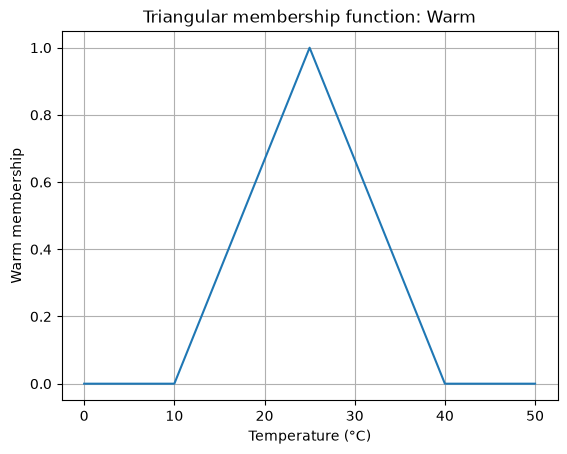

In [8]:
temperatures = np.linspace(0, 50, 101)
warm_values = [warm_membership(t) for t in temperatures]

plt.plot(temperatures, warm_values)
plt.xlabel("Temperature (°C)")
plt.ylabel("Warm membership")
plt.title("Triangular membership function: Warm")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.show()


The graph goes up from 10 to 25. Then it goes down from 25 to 40. Outside, it is 0.


## 7. Fuzzy AND, OR, NOT

For this lesson:

- A AND B = \(\min(\mu_A, \mu_B)\)
- A OR B = \(\max(\mu_A, \mu_B)\)
- NOT A = \(1 - \mu_A\)

Given:

- Hot = 0.8
- High Humidity = 0.6


In [9]:
hot = 0.8
humid = 0.6

fuzzy_and = min(hot, humid)
fuzzy_or = max(hot, humid)
not_hot = 1 - hot
not_humid = 1 - humid

print("Hot AND Humid =", fuzzy_and)
print("Hot OR Humid =", fuzzy_or)
print("NOT Hot =", not_hot)
print("NOT Humid =", not_humid)


Hot AND Humid = 0.6
Hot OR Humid = 0.8
NOT Hot = 0.19999999999999996
NOT Humid = 0.4


### What I see

- AND uses the weaker condition. \(\min(0.8, 0.6) = 0.6\)
- OR uses the stronger condition. \(\max(0.8, 0.6) = 0.8\)
- NOT reverses the membership. NOT Hot = 0.2. NOT Humid = 0.4


## 8. Fuzzy rule strength

Rule:

**IF temperature is Hot AND humidity is High THEN fan speed is Fast**

Suppose:

- Hot = 0.8
- High Humidity = 0.6

The rule uses AND, so:

\[
\text{Rule strength} = \min(0.8, 0.6) = 0.6
\]

**What does 0.6 mean?**  
The rule is on with strength 0.6. It does **not** mean the fan speed is 0.6. Humidity is the weaker part, so it limits the rule.


In [10]:
hot = 0.8
high_humidity = 0.6

rule_strength = min(hot, high_humidity)

print("Rule strength =", rule_strength)


Rule strength = 0.6


## 9. Independent challenge

I do this without copying the teacher example.

Given:

- \(x_1 = 1\)
- \(x_2 = 1\)
- \(w_1 = 0.3\)
- \(w_2 = 0.7\)
- \(b = -0.4\)
- correct target \(y = 1\)

### Neural-network tasks (by hand)

**1. Calculate \(z\)**

\[
z = 1 \times 0.3 + 1 \times 0.7 + (-0.4) = 0.3 + 0.7 - 0.4 = 0.6
\]

**2. Calculate sigmoid prediction**

\[
\hat{y} = \frac{1}{1 + e^{-0.6}}
\]

\(e^{-0.6} \approx 0.5488\)

\[
\hat{y} \approx \frac{1}{1.5488} \approx 0.6457
\]

**3. Convert prediction to class**  
\(0.6457 > 0.5\), so the class is **1**.

**4. Calculate squared-error loss**

\[
\text{loss} = (1 - 0.6457)^2 \approx 0.3543^2 \approx 0.1255
\]

### Student workspace — Neural network


In [11]:
# My numbers for this task
in1 = 1
in2 = 1
weight1 = 0.3
weight2 = 0.7
bias = -0.4
target = 1

z_task = in1 * weight1 + in2 * weight2 + bias
pred_task = 1 / (1 + math.exp(-z_task))
class_task = int(pred_task >= 0.5)
loss_task = (target - pred_task) ** 2

print("z =", z_task)
print("sigmoid prediction =", pred_task)
print("predicted class =", class_task)
print("squared-error loss =", loss_task)


z = 0.6
sigmoid prediction = 0.6456563062257954
predicted class = 1
squared-error loss = 0.12555945331754728


Python matches my hand work: \(z=0.6\), prediction about 0.646, class 1, loss about 0.126.

### Fuzzy tasks

Let:

- Hot = 0.4
- High Humidity = 0.9

By hand:

1. Hot AND High Humidity = \(\min(0.4, 0.9) = 0.4\)
2. Hot OR High Humidity = \(\max(0.4, 0.9) = 0.9\)
3. NOT Hot = \(1 - 0.4 = 0.6\)
4. NOT High Humidity = \(1 - 0.9 = 0.1\)
5. Rule: IF Hot AND High Humidity THEN Fan Fast → strength = **0.4**

The weak part is Hot (0.4), so AND and the rule are both 0.4.

### Student workspace — Fuzzy logic


In [12]:
mu_hot = 0.4
mu_humid = 0.9

and_value = min(mu_hot, mu_humid)
or_value = max(mu_hot, mu_humid)
not_hot_value = 1 - mu_hot
not_humid_value = 1 - mu_humid
fan_rule = min(mu_hot, mu_humid)

print("Hot AND High Humidity =", and_value)
print("Hot OR High Humidity =", or_value)
print("NOT Hot =", not_hot_value)
print("NOT High Humidity =", not_humid_value)
print("Rule strength (Fan Fast) =", fan_rule)


Hot AND High Humidity = 0.4
Hot OR High Humidity = 0.9
NOT Hot = 0.6
NOT High Humidity = 0.09999999999999998
Rule strength (Fan Fast) = 0.4


## 10. Short defense questions

I answer in my own words.

**1. What does \(z\) mean in a neuron?**  
\(z\) is the weighted sum of the inputs plus the bias. It is the number before sigmoid.

**2. What does sigmoid do?**  
Sigmoid takes \(z\) and turns it into a number between 0 and 1.

**3. What does loss measure?**  
Loss measures how wrong the prediction is. Here I use \((y - \text{prediction})\) squared.

**4. If \(y=1\), what happens to loss when prediction approaches 1?**  
Loss gets smaller. It goes toward 0.

**5. Is the gradient fixed during training?**  
No. The gradient can change at each step. Training calculates it again and again.

**6. What does learning rate control?**  
It controls how big one update is. A small learning rate means a small step.

**7. What does fuzzy membership 0.7 mean?**  
The value belongs to the fuzzy set with strength 0.7. It is not full yes and not full no.

**8. Why can one temperature belong partly to Warm and partly to Hot?**  
Fuzzy sets can overlap. 30°C can be a bit warm and a bit hot at the same time.

**9. How do we calculate fuzzy AND?**  
We take the minimum of the two membership values.

**10. What does rule strength 0.6 mean?**  
The rule is activated with strength 0.6. It is not the output value itself, like fan speed.

## Final summary

Today I practiced:

**Neural network**  
inputs → weighted sum \(z\) → activation → prediction → loss → weight update idea

**Fuzzy logic**  
real value → membership degree → fuzzy AND/OR/NOT → rule strength

**The important difference:**  
A neural-network output is learned from data. A fuzzy membership degree says how strongly a value belongs to a fuzzy idea.
